## 1.5 Feature Engineering and External Data Enrichment

After missing values and semantic plausibility have been analyzed, additional variables are prepared to make the trip data useful for demand prediction and later fleet-related decisions. The goal is not to create as many features as possible, but to create only features that are clearly connected to the business questions.

The most important features are temporal features derived from `trip_start_timestamp`. Demand is expected to differ by hour, weekday, weekend, month, and season. Therefore, features such as `hour`, `day_of_week`, `is_weekend`, `month`, and `date` can be created. These features directly support the question of when demand occurs.

Spatial information is mainly prepared rather than newly created. Community Area and Census Tract identifiers already exist in the raw dataset and can be used later for aggregation after missing value checks. Census Tracts must be used carefully because they contain many missing values. H3 or hexagon identifiers, however, need to be newly created from pickup centroid coordinates.

Trip duration and trip distance are not direct causes of pickup demand, but they are useful for operational interpretation. Areas with the same number of pickups may still require different fleet sizes if trips differ strongly in length or duration. Therefore, features like `avg_speed_mph` are relevant for later utilization, charging, and repositioning analysis.

Monetary variables such as `trip_total`, price per mile, or price per minute are less central for the initial demand prediction task because they describe the realized trip rather than the demand event itself. They should therefore not be treated as core predictors of demand. However, features such as `price_per_mile` or `price_per_minute` may be useful later for assessing revenue potential or market attractiveness.

External data should be added with expected link to demand. Weather (`temperature`, `precipitation`, `snowfall`) should be linked to transactional rides. Regarding re-positioning especially the location of charging hubs may be really interesting to know. 

The main steps in this section include:

- creating temporal features from `trip_start_timestamp` (`hour`, `day_of_week`, `is_weekend`, `month`, `date`)
- creating H3 / hexagon identifiers from pickup centroid coordinates (`pickup_h3`)
- calculating selected operational trip-level features (`avg_speed_mph`)
- monetary features only for later business interpretation (`price_per_mile`, `price_per_minute`)
- enriching the dataset with weather data (`temperature`, `precipitation`)

For the initial demand model, the core features are time and pickup location. Distance, duration, dropoff, monetary, and external variables are mainly used for later interpretation, fleet planning, charging strategy, and economic assessment.

### Temporal features

Demand varies systematically over time. Pickups are not uniformly distributed across the day, the week, or the year - peaks during commuting hours, weekend evenings, and seasonal events are well documented for urban taxi services. Five lightweight features derived from `trip_start_timestamp` are sufficient to capture the main temporal drivers and to act as join keys for later aggregation.

- `hour` (0-23): captures intra-day demand cycles
- `day_of_week` (0=Monday): captures weekly cycles
- `is_weekend`: a binary flag derived from `day_of_week`, useful for splits and grouped aggregations
- `month`: a proxy for seasonal effects, since the dataset covers 2024 onwards
- `date`: required for daily aggregations and for joining external daily data

These features are created on the trip-level dataset and remain available after later aggregation.

In [1]:
import pandas as pd

In [2]:

df_full = pd.read_parquet("../processed/df_task1_cleaned.parquet")
hard_exclude = pd.read_pickle("../processed/hard_exclude.pkl")

In [3]:
# Temporal features derived from trip_start_timestamp
df_full["hour"]        = df_full["trip_start_timestamp"].dt.hour.astype("int8")
df_full["day_of_week"] = df_full["trip_start_timestamp"].dt.dayofweek.astype("int8")  # Mon=0, Sun=6
df_full["is_weekend"]  = df_full["day_of_week"].isin([5, 6])
df_full["month"]       = df_full["trip_start_timestamp"].dt.month.astype("int8")
# `date` kept as normalized datetime64 (midnight) rather than python date objects:
# identical nunique()/grouping behaviour, but a fraction of the memory on 15M rows.
df_full["date"]        = df_full["trip_start_timestamp"].dt.normalize()

# Quick sanity check
df_full[["trip_start_timestamp", "hour", "day_of_week", "is_weekend", "month", "date"]].head(10)


,trip_start_timestamp,hour,day_of_week,is_weekend,month,date
0,2026-04-01,0,2,False,4,2026-04-01
1,2026-04-01,0,2,False,4,2026-04-01
2,2026-04-01,0,2,False,4,2026-04-01
3,2026-04-01,0,2,False,4,2026-04-01
4,2026-04-01,0,2,False,4,2026-04-01
5,2026-04-01,0,2,False,4,2026-04-01
6,2026-04-01,0,2,False,4,2026-04-01
7,2026-04-01,0,2,False,4,2026-04-01
8,2026-04-01,0,2,False,4,2026-04-01
9,2026-04-01,0,2,False,4,2026-04-01


All five features are derived from a single source column, so they are internally consistent and inherit the missing-value behaviour of `trip_start_timestamp`. Since `trip_start_timestamp` has no missing values after the cleaning steps in 1.2, no additional handling is required for the temporal features.

### Spatial feature: H3 hexagon identifier

Community Area and Census Tract identifiers are already in the dataset. H3 hexagons, however, are not - they have to be derived from the pickup centroid coordinates. H3 produces a fixed, regular grid that is independent of administrative boundaries. This makes results comparable across districts of different size and avoids the high missing-value share of Census Tracts.

H3 supports multiple resolutions. Resolution 8 is used here as the default: the average hexagon area is about 0.74 km² (edge length ~460 m), which is finer than a typical Chicago Community Area (~5 km²) and coarser than a Census Tract. This is a common choice for ride-hailing studies and a reasonable starting point; alternative resolutions can be created in the same way for the sensitivity analysis in section 1.6.

Only rows with non-missing pickup latitude **and** longitude can be assigned a hexagon. From section 1.3, this affects about 2.74% of all rows.

In [4]:
import h3

# Resolution 8: ~0.74 km^2 per hexagon (~460 m edge)
# Finer than Community Area, coarser than Census Tract
H3_RESOLUTION = 8

# Coordinates must be present on both axes - guard against the ~2.74% missing rows from 1.3
valid_coords = (
    df_full["pickup_centroid_latitude"].notna()
    & df_full["pickup_centroid_longitude"].notna()
)

df_full["pickup_h3"] = pd.NA
df_full.loc[valid_coords, "pickup_h3"] = [
    h3.latlng_to_cell(lat, lng, H3_RESOLUTION)
    for lat, lng in zip(
        df_full.loc[valid_coords, "pickup_centroid_latitude"],
        df_full.loc[valid_coords, "pickup_centroid_longitude"],
    )
]
df_full["pickup_h3"] = df_full["pickup_h3"].astype("string")

print(f"Rows with pickup_h3:               {df_full['pickup_h3'].notna().sum():>10,} "
      f"({df_full['pickup_h3'].notna().mean()*100:.2f}%)")
print(f"Rows without pickup_h3 (missing):  {df_full['pickup_h3'].isna().sum():>10,} "
      f"({df_full['pickup_h3'].isna().mean()*100:.2f}%)")
print(f"Unique H3 cells at resolution {H3_RESOLUTION}:  {df_full['pickup_h3'].nunique():>10,}")

Rows with pickup_h3:               14,397,030 (97.26%)
Rows without pickup_h3 (missing):     405,819 (2.74%)
Unique H3 cells at resolution 8:         475


`pickup_h3` is available for the same share of rows as the pickup centroid coordinates. Trips without coordinates remain in the trip-level dataset (they still represent demand and are kept for Community-Area-level aggregations) but they are dropped automatically when grouping on `pickup_h3`. The number of distinct cells gives a first indication of the achievable spatial resolution, which will be compared against the number of Community Areas (77) in section 1.6.

### Operational feature: average trip speed

Trip distance and trip duration are not direct causes of pickup demand - they describe what happens after a pickup. They are still relevant for the later operational view: two areas with the same number of pickups can require different fleet sizes if their trips are systematically faster or slower (range, charging frequency, repositioning needs).

`avg_speed_mph` is therefore added as a trip-level operational feature. It is computed only on rows where the inputs are usable. From section 1.4, the relevant filters are:

- `trip_miles > 0` and `trip_miles <= 100`  (excludes `zero_miles` and `extreme_miles`)
- `trip_seconds > 0` and `trip_seconds <= 10_800`  (excludes `invalid_seconds` and `extreme_seconds`)
- `trip_end_timestamp >= trip_start_timestamp`  (excludes `end_before_start`)

For all other rows, `avg_speed_mph` is set to NA. The rows themselves stay in the dataset because they still count as valid demand events.

In [5]:
# avg_speed_mph: trip_miles / trip_hours, only on rows where both inputs are usable
# Conditions are recomputed inline so this section is independent of variables defined in 1.4

valid_distance = (df_full["trip_miles"] > 0) & (df_full["trip_miles"] <= 100)
valid_duration = (df_full["trip_seconds"] > 0) & (df_full["trip_seconds"] <= 10_800)
chronological = df_full["trip_end_timestamp"] >= df_full["trip_start_timestamp"]

speed_calculable = valid_distance & valid_duration & chronological

df_full["avg_speed_mph"] = pd.NA
df_full.loc[speed_calculable, "avg_speed_mph"] = (
    df_full.loc[speed_calculable, "trip_miles"]
    / (df_full.loc[speed_calculable, "trip_seconds"] / 3600)
)
df_full["avg_speed_mph"] = pd.to_numeric(df_full["avg_speed_mph"], errors="coerce")

print(f"avg_speed_mph available: {df_full['avg_speed_mph'].notna().sum():,} rows "
      f"({df_full['avg_speed_mph'].notna().mean()*100:.2f}%)")
print()
print(df_full["avg_speed_mph"].describe(percentiles=[.05, .5, .95, .99]))


avg_speed_mph available: 13,483,311 rows (91.09%)

count    1.348331e+07
mean     8.560617e+01
std      3.811518e+02
min      3.493450e-03
5%       6.105600e-01
50%      3.560330e+00
95%      2.983333e+02
99%      2.346667e+03
max      1.252800e+04
Name: avg_speed_mph, dtype: float64


In [6]:
valid_distance = (df_full["trip_miles"] > 0) & (df_full["trip_miles"] <= 100)
valid_duration = (df_full["trip_seconds"] >= 60) & (df_full["trip_seconds"] <= 10_800)  # 60s minimum added
chronological = df_full["trip_end_timestamp"] >= df_full["trip_start_timestamp"]

speed_calculable = valid_distance & valid_duration & chronological

df_full["avg_speed_mph"] = pd.NA
df_full.loc[speed_calculable, "avg_speed_mph"] = (
    df_full.loc[speed_calculable, "trip_miles"]
    / (df_full.loc[speed_calculable, "trip_seconds"] / 3600)
)
df_full["avg_speed_mph"] = pd.to_numeric(df_full["avg_speed_mph"], errors="coerce")

# Cap at 80 mph — reasonable upper bound for urban/highway taxi driving
df_full["avg_speed_mph"] = df_full["avg_speed_mph"].clip(upper=80)

print(f"avg_speed_mph available: {df_full['avg_speed_mph'].notna().sum():,} rows "
      f"({df_full['avg_speed_mph'].notna().mean()*100:.2f}%)")
print()
print(df_full["avg_speed_mph"].describe(percentiles=[.05, .5, .95, .99]))

avg_speed_mph available: 13,167,068 rows (88.95%)

count    1.316707e+07
mean     1.800307e+01
std      2.484556e+01
min      3.493450e-03
5%       6.056075e-01
50%      3.036285e+00
95%      8.000000e+01
99%      8.000000e+01
max      8.000000e+01
Name: avg_speed_mph, dtype: float64


In [7]:
# Check trip characteristics for very slow trips (< 2 mph)
slow_trips = df_full["avg_speed_mph"] < 2

print(f"Trips with avg_speed_mph < 2: {slow_trips.sum():,} ({slow_trips.mean()*100:.2f}%)")
print()
print(df_full.loc[slow_trips, ["trip_miles", "trip_seconds"]].describe(percentiles=[.25, .5, .75, .95]))

Trips with avg_speed_mph < 2: 5,968,899 (40.32%)

       trip_miles  trip_seconds
count   5968899.0     5968899.0
mean     1.482833   5224.463144
std       0.91751   2286.794285
min          0.01          60.0
25%          0.83        3550.0
50%           1.3        5110.0
75%          1.93        6940.0
95%           3.3        9120.0
max           5.7       10799.0


After applying a minimum duration of 60 seconds and an 80 mph cap, the high end of the distribution is cleanly bounded and the mean of 18 mph is plausible for urban Chicago taxi traffic.

However, 40% of trips fall below 2 mph, with a median of 1.3 miles in 85 minutes — these are not short trips but trips where metered time is dominated by waiting, congestion, and idle time rather than driving. This means `avg_speed_mph` does not measure actual driving speed but reflects how much distance was covered per hour of metered time, including all waiting.

Despite this limitation, the feature is retained as a rough operational efficiency indicator. Areas with consistently low `avg_speed_mph` signal high congestion or short-haul demand patterns, which is relevant for fleet repositioning and charging decisions. It is not used as a predictor in the demand model.

### Monetary features for later business interpretation

Price-related variables are not used as predictors for the initial demand model. They describe the realised trip after the pickup decision, so using them as inputs for demand prediction would mix outcome and predictor. They are still useful later, when the question shifts from "where is demand" to "where is demand worth serving" — for example when comparing revenue potential across spatial units.

Two ratios are added at trip level:

- `price_per_mile` = `trip_total` / `trip_miles`
- `price_per_minute` = `trip_total` / (`trip_seconds` / 60)

Both require a positive denominator and a plausible `trip_total`. From section 1.4, `extreme_total` (`trip_total > 200`) is excluded because it dominates ratios disproportionately. As before, the row itself is kept; only the ratio is NA when inputs are not usable.

In [8]:
# Reuse the same plausibility windows defined for the speed feature
valid_total = (
    df_full["trip_total"].notna()
    & (df_full["trip_total"] > 0)
    & (df_full["trip_total"] <= 200)
)

ppm_calc = valid_total & valid_distance
df_full["price_per_mile"] = pd.NA
df_full.loc[ppm_calc, "price_per_mile"] = (
    df_full.loc[ppm_calc, "trip_total"] / df_full.loc[ppm_calc, "trip_miles"]
)
df_full["price_per_mile"] = pd.to_numeric(df_full["price_per_mile"], errors="coerce")

ppmin_calc = valid_total & valid_duration
df_full["price_per_minute"] = pd.NA
df_full.loc[ppmin_calc, "price_per_minute"] = (
    df_full.loc[ppmin_calc, "trip_total"] / (df_full.loc[ppmin_calc, "trip_seconds"] / 60)
)
df_full["price_per_minute"] = pd.to_numeric(df_full["price_per_minute"], errors="coerce")

print(df_full[["price_per_mile", "price_per_minute"]]
      .describe(percentiles=[.05, .5, .95, .99]))

       price_per_mile  price_per_minute
count    1.346784e+07      1.399335e+07
mean     1.756091e+01      2.576941e+00
std      2.053261e+02      6.397280e+00
min      1.019264e-04      5.558644e-05
5%       2.640693e+00      8.118557e-02
50%      4.475308e+00      3.571429e-01
95%      1.600000e+01      1.448148e+01
99%      1.083333e+02      2.830936e+01
max      2.000000e+04      2.000000e+02


### External enrichment: weather

Weather affects ride demand in two opposite directions. Light rain or cold typically increases demand because people avoid walking and public transit, while heavy snowfall reduces overall mobility. Without weather data, day-level demand spikes that are actually driven by weather would be attributed to the calendar instead.

Hourly and daily observations for Chicago are obtained from Open-Meteo's Historical Weather API. 
- Hourly data: https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&start_date=2024-01-01&timezone=America%2FChicago&end_date=2026-04-01&wind_speed_unit=mph&precipitation_unit=inch&temperature_unit=fahrenheit&hourly=temperature_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
- Daily data: https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&start_date=2024-01-01&timezone=America%2FChicago&end_date=2026-04-01&hourly=&wind_speed_unit=mph&precipitation_unit=inch&temperature_unit=fahrenheit&daily=weather_code,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max
 
Both downloads cover the full date range of the trip dataset (2024-01-01 to 2026-04-01) and use Chicago local time. The Chicago centroid was chosen as the location (latitude: 41.85, longitude: -87,65) but the weather model has a 9 km resolution, so e.g. a north/south/east/west-split could be applied later in the process, if necessary.

The following columns are included:

**Hourly weather data (`df_weather_hours`)**

| Column | Description |
|---|---|
| `timestamp_h` | Hourly timestamp in Chicago local time — used as the join key to merge weather onto trip-level data |
| `temp_h` | Air temperature at 2 m above ground in °F, instantaneous value at the indicated hour |
| `rain_h` | Liquid precipitation sum of the preceding hour in inches — excludes snowfall |
| `snow_h` | Snowfall sum of the preceding hour in inches |
| `precip_h` | Total precipitation sum of the preceding hour in inches — includes rain, showers, and snowfall |
| `wind_speed_h` | Wind speed at 10 m above ground in mph, instantaneous value at the indicated hour |
| `weather_code_h` | WMO weather condition code at the indicated hour — numeric code encoding general conditions such as clear sky, rain, or snow |

**Daily weather data (`df_weather_days`)**

| Column | Description |
|---|---|
| `timestamp_d` | Daily timestamp in Chicago local time — used as the join key for day-level aggregations |
| `weather_code_d` | Most severe WMO weather condition code recorded on that day |
| `temp_mean_d` | Mean air temperature at 2 m above ground in °F, averaged over the full day |
| `sunshine_hours_d` | Total sunshine duration on the day in hours — sunshine is defined as direct solar irradiance exceeding 120 W/m² |
| `precip_sum_d` | Total precipitation sum for the day in inches — includes rain, showers, and snowfall |
| `rain_sum_d` | Total liquid rain sum for the day in inches |
| `snow_sum_d` | Total snowfall sum for the day in inches |
| `precip_hours_d` | Number of hours with measurable precipitation on the day |
| `wind_speed_max_d` | Maximum wind speed at 10 m above ground recorded on the day in mph |

In [9]:
# Load weather data 
df_weather_hours = pd.read_csv("../data/chicago_weather_hourly.csv", skiprows=3)
df_weather_days = pd.read_csv("../data/chicago_weather_daily.csv", skiprows=3)

# Print column names of both weather datasets
print("Columns in df_weather_hours:")
print(df_weather_hours.columns.tolist())
print("Columns in df_weather_days:")
print(df_weather_days.columns.tolist())

print(df_weather_days.head())
print(df_weather_hours.head())

Columns in df_weather_hours:
['time', 'temperature_2m (°F)', 'rain (inch)', 'snowfall (inch)', 'precipitation (inch)', 'wind_speed_10m (mp/h)', 'weather_code (wmo code)']
Columns in df_weather_days:
['time', 'weather_code (wmo code)', 'temperature_2m_mean (°F)', 'sunshine_duration (s)', 'precipitation_sum (inch)', 'rain_sum (inch)', 'snowfall_sum (inch)', 'precipitation_hours (h)', 'wind_speed_10m_max (mp/h)']
         time  weather_code (wmo code)  temperature_2m_mean (°F)  \
0  2024-01-01                       71                      31.2   
1  2024-01-02                        3                      29.2   
2  2024-01-03                        3                      32.2   
3  2024-01-04                        3                      29.3   
4  2024-01-05                        3                      29.0   

   sunshine_duration (s)  precipitation_sum (inch)  rain_sum (inch)  \
0               29168.42                     0.016              0.0   
1               23716.41           

In [10]:
# Change sunshine_duration from seconds to hours for better interpretability
df_weather_days["sunshine_duration (s)"] = df_weather_days["sunshine_duration (s)"] / 3600

# Convert time columns to datetime
df_weather_hours["time"] = pd.to_datetime(df_weather_hours["time"])

# Rename columns for clarity and consistency
df_weather_hours.rename(columns={
    "time": "timestamp_h",
    "temperature_2m (°F)": "temp_h",
    "rain (inch)": "rain_h",
    "snowfall (inch)": "snow_h",
    "precipitation (inch)": "precip_h",
    "wind_speed_10m (mp/h)": "wind_speed_h",
    "weather_code (wmo code)": "weather_code_h"
}, inplace=True)

df_weather_days.rename(columns={
    "time": "timestamp_d",
    "weather_code (wmo code)": "weather_code_d",
    "temperature_2m_mean (°F)": "temp_mean_d",
    "sunshine_duration (s)": "sunshine_hours_d",
    "precipitation_sum (inch)": "precip_sum_d",
    "rain_sum (inch)": "rain_sum_d",
    "snowfall_sum (inch)": "snow_sum_d",
    "precipitation_hours (h)": "precip_hours_d",
    "wind_speed_10m_max (mp/h)": "wind_speed_max_d"
}, inplace=True)

print(df_weather_days.head())
print(df_weather_hours.head())

  timestamp_d  weather_code_d  temp_mean_d  sunshine_hours_d  precip_sum_d  \
0  2024-01-01              71         31.2          8.102339         0.016   
1  2024-01-02               3         29.2          6.587892         0.000   
2  2024-01-03               3         32.2          1.676578         0.000   
3  2024-01-04               3         29.3          8.179997         0.000   
4  2024-01-05               3         29.0          7.104625         0.000   

   rain_sum_d  snow_sum_d  precip_hours_d  wind_speed_max_d  
0         0.0        0.11             4.0              18.9  
1         0.0        0.00             0.0              16.8  
2         0.0        0.00             0.0              10.7  
3         0.0        0.00             0.0              12.3  
4         0.0        0.00             0.0              10.9  
          timestamp_h  temp_h  rain_h  snow_h  precip_h  wind_speed_h  \
0 2024-01-01 00:00:00    33.0     0.0   0.028     0.004          18.9   
1 2024-01-01 

In [11]:
# Aggregate hourly weather into 4-hour bins
# Floor timestamp to 4-hour intervals (00:00, 04:00, 08:00, 12:00, 16:00, 20:00)
df_weather_4hours = (
    df_weather_hours
    .copy()
    .assign(timestamp_4h=lambda x: x["timestamp_h"].dt.floor("4h"))
    .groupby("timestamp_4h")
    .agg(
        temp_4h=("temp_h", "mean"),          # average temperature over the 4-hour window
        rain_4h=("rain_h", "sum"),            # total liquid rain in the 4-hour window
        snow_4h=("snow_h", "sum"),            # total snowfall in the 4-hour window
        precip_4h=("precip_h", "sum"),        # total precipitation in the 4-hour window
        wind_speed_4h=("wind_speed_h", "mean"),  # average wind speed over the 4-hour window
        weather_code_4h=("weather_code_h", "max"),  # most severe weather code in the window
    )
    .reset_index()
)

df_weather_4hours.head()

,timestamp_4h,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,2024-01-01 00:00:00,32.950,0.0,0.112,0.016,18.450,71
1,2024-01-01 04:00:00,31.450,0.0,0.000,0.000,14.775,3
2,2024-01-01 08:00:00,30.000,0.0,0.000,0.000,10.850,3
3,2024-01-01 12:00:00,33.625,0.0,0.000,0.000,8.450,2
4,2024-01-01 16:00:00,30.950,0.0,0.000,0.000,8.025,0


We use a single weather station for Chicago. Hourly interpolation was intentionally avoided because:

- Weather changes gradually — variations within short intervals are negligible and have minimal impact on taxi demand.
- Inefficient trade-off — interpolating hourly adds computational overhead while providing little to no improvement in accuracy.

### Summary of features and datasets created in 1.5

The trip-level dataset `df_full` now contains the following new columns:

| Group | Column | Used for the initial demand model? | Notes |
|---|---|---|---|
| Temporal | `hour`, `day_of_week`, `is_weekend`, `month`, `date` | Yes | Core temporal predictors and join keys |
| Spatial | `pickup_h3` | Yes | Alternative spatial unit to Community Area / Census Tract, resolution 8 |
| Operational | `avg_speed_mph` | No | Fleet utilisation, repositioning, charging frequency |
| Monetary | `price_per_mile`, `price_per_minute` | No | Revenue potential and economic attractiveness |

Three additional weather dataframes are prepared as separate tables and not yet merged into `df_full`:

| Dataframe | Granularity | Join key | Intended use in 1.6 |
|---|---|---|---|
| `df_weather_hours` | Hourly | `timestamp_h` | Merge onto hourly aggregations |
| `df_weather_4hours` | 4-hour bins (00, 04, 08, 12, 16, 20) | `timestamp_4h` | Merge onto 4-hour aggregations |
| `df_weather_days` | Daily | `timestamp_d` | Merge onto daily aggregations |

The weather merges are deferred to 1.6 because weather variables describe time, not individual trips. Merging them onto every trip row would duplicate the same hourly values 15 million times. The aggregation step is the natural join point.

In line with the missing-value strategy from 1.3 and the flag-based exclusion logic from 1.4, no rows are dropped at this stage. Features that cannot be computed for a given row are stored as NA, so trip counts remain unchanged and the row continues to contribute to all aggregations for which its inputs are valid.

## 1.6 Spatial and Temporal Aggregation

After feature engineering, the trip-level dataset is transformed into demand observations: one row per (spatial unit × time bucket), with `demand_count` (number of pickups) as the main target variable.

The aggregation logic is resolution-agnostic — it works for any spatial unit (Community Area, Census Tract, or H3 hexagons at resolutions 4–9) and any temporal bin (1h, 4h, 8h, 1d). Rather than materialise every combination here, this section defines the reusable aggregation function and produces a single canonical dataset at **H3 resolution 6 × 4 hour**, the starting point for the predictive modelling in Section 3. Other resolutions are generated on demand in Section 2 (descriptive analytics) and 2.7 (resolution sensitivity), working directly from the persisted trip-level data.

H3 r6 × 4h is adopted as a reasoned default, not a proven optimum: 4-hourly is one of the temporal bins suggested in the task, a mid-range hexagon size balances spatial detail against target sparsity, and a single canonical dataset is needed to drive Task 3. Section 2.7 tests this choice explicitly against finer and coarser resolutions.

Steps:
- Step 1 — filter to rows eligible for aggregation (hard exclusions)
- Step 2 — assign H3 cell IDs at resolutions 4–9
- Step 3 — assign time buckets (1h, 4h, 8h, 1d)
- Step 4 — define the aggregation function (demand_count + trip characteristics) and the zero-fill helper
- Step 5 — build the canonical H3 r6 × 4h dataset and enrich with weather
- Step 6 — compute idle time

In [12]:
import matplotlib.pyplot as plt

In [13]:
df_full.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,dropoff_centroid__location,hour,day_of_week,is_weekend,month,date,pickup_h3,avg_speed_mph,price_per_mile,price_per_minute
0,6c54cdb22905b181c23527e74c2b653a503107b7,db757f6c1157d9f81e266396132cd641837c189b803c52...,2026-04-01,2026-04-01 00:15:00,1407,14.35,NaN,NaN,76.0,22.0,...,POINT (-87.6991553432 41.9227606205),0,2,False,4,2026-04-01,8827593433fffff,36.716419,3.345644,2.047335
1,6cd5d74b7ec8d7d230387900d72d74326dfb31de,f509c57d2f0b196f54d9b751ce2a1b6e956f378841b1e8...,2026-04-01,2026-04-01 00:15:00,1701,19.139999,17031980000.0,17031320100.0,76.0,32.0,...,POINT (-87.6209929134 41.8849871918),0,2,False,4,2026-04-01,88275934edfffff,40.507935,3.160920,2.134039
2,d36a90d961ed60add20ab3a4a7a8ca98bd2bf929,4136627ef25b9fad79910c55679c02d8e1f2a42925d29c...,2026-04-01,2026-04-01 00:15:00,126,10.2,NaN,NaN,76.0,14.0,...,POINT (-87.7215590627 41.968069),0,2,False,4,2026-04-01,8827593433fffff,80.000000,3.063725,14.880952
3,cb1fed57e7eeea1db20758256b754201f5e13e07,c9bda81f1aaad786527911c983b6be11f28c6f46469e1a...,2026-04-01,2026-04-01 00:30:00,1608,18.4,NaN,NaN,76.0,32.0,...,POINT (-87.6251921424 41.8788655841),0,2,False,4,2026-04-01,8827593433fffff,41.194029,2.744565,1.884328
4,d3c33c166fdbca45d040772d18bd1ae1dc669ade,f71223a469d78a2f65a090adc9d4fb5ae08dfc6694c650...,2026-04-01,2026-04-01 00:00:00,4220,0.98,NaN,NaN,32.0,28.0,...,POINT (-87.6635175498 41.874005383),0,2,False,4,2026-04-01,882664c1a9fffff,0.836019,6.122449,0.085308


### Step 1: Filter data for aggregation: apply hard exclusions

In [14]:
import gc

# Filter to rows eligible for aggregation: hard exclusions + present pickup coordinates.
mask_coords = (
    df_full["pickup_centroid_latitude"].notna()
    & df_full["pickup_centroid_longitude"].notna()
)
df = df_full[~hard_exclude & mask_coords].copy()

n_removed = hard_exclude.sum()
print(f"Rows removed by hard exclusions : {n_removed:>10,}  ({hard_exclude.mean()*100:.2f}%)")
print(f"Rows remaining in df            : {len(df):>10,} ({(~hard_exclude).mean()*100:.2f}%)")

# df_full is not referenced anywhere after this point — free ~5 GB before the
# H3 loops and aggregation run. (Re-run the notebook from the top to recreate it.)
if 'df_full' in dir():
    del df_full
gc.collect()


Rows removed by hard exclusions :     13,024  (0.09%)
Rows remaining in df            : 14,382,862 (99.91%)


0

### Step 2: Define spatial resolution

Size of Chicago (see https://www.britannica.com/place/Chicago): 
- 228 square miles
- 25 miles north to south
- 15 miles east to west 

Size of h3 resolutions (see https://h3geo.org/docs/core-library/restable/):

| Resolution | avg. hexagon area [mi^2] | avg. edge length [mi] |
| --- | --- | --- |
| 4 | ~683.53mi^2 | ~16.20mi |
| 5 | ~97.65mi^2 | 6.12mi |
| 6 | ~13.95mi^2 | 2.31mi |
| 7 | ~1.99mi^2 | 0.87mi |
| 8 | ~0.28mi^2 | 0.33mi |

In [15]:
# Assign H3 cell IDs at the resolutions actually used downstream:
#   r6 = canonical (Task 3), r4 + r8 = resolution sensitivity (2.7), r5/r7 = optional context.
# r9 is dropped: nothing in Task 2/3 uses it and it is the heaviest string column.
# Coordinate arrays are pulled out of the loop (they do not change with resolution).
lats = df["pickup_centroid_latitude"].to_numpy()
lngs = df["pickup_centroid_longitude"].to_numpy()
for res in [4, 5, 6, 7, 8]:
    df[f"h3_r{res}"] = pd.Categorical(
        [h3.latlng_to_cell(lat, lng, res) for lat, lng in zip(lats, lngs)]
    )


In [16]:
print("unique h3_r4:", df["h3_r4"].nunique())
print("unique h3_r5:", df["h3_r5"].nunique())
print("unique h3_r6:", df["h3_r6"].nunique())
print("unique h3_r7:", df["h3_r7"].nunique())
print("unique h3_r8:", df["h3_r8"].nunique())
print("unique community areas:", df["pickup_community_area"].nunique())
print("unique census tracts:", df["pickup_census_tract"].nunique())
print(df["h3_r6"].value_counts().head(10))

unique h3_r4: 4
unique h3_r5: 8
unique h3_r6: 27
unique h3_r7: 128
unique h3_r8: 475
unique community areas: 77
unique census tracts: 607
h3_r6
862664c1fffffff    6735700
862759347ffffff    2972725
862664c17ffffff     942779
862664cafffffff     878159
862664d8fffffff     647601
862664527ffffff     437289
862664cc7ffffff     370007
862664cf7ffffff     325052
862664ca7ffffff     212204
862664ccfffffff     164452
Name: count, dtype: int64


### Step 3: Define temporal resolution
| Column | Resolution | Description |
|---|---|---|
| `time_1h` | 1 hour | Floor to the nearest hour |
| `time_4h` | 4 hours | Floor to the nearest 4-hour window (00, 04, 08, 12, 16, 20) |
| `time_8h` | 8 hours | Floor to the nearest 8-hour window |
| `time_1d` | 1 day | Floor to the nearest day |

Flooring (not rounding) assigns each trip to the bucket in which it started.

In [17]:
df["time_1h"] = df["trip_start_timestamp"].dt.floor("h")
df["time_4h"] = df["trip_start_timestamp"].dt.floor("4h")
df["time_8h"] = df["trip_start_timestamp"].dt.floor("8h")
df["time_1d"] = df["trip_start_timestamp"].dt.floor("D")

### Step 4: Aggregation function and zero-fill

`aggregate_demand(df, location_col, time_col)` returns one row per (location, time) pair:

| Column | Description |
|---|---|
| `demand_count` | Number of pickups — the main target variable |
| `avg_trip_miles` | Mean trip distance (zero-mile trips excluded via `NaN`) |
| `avg_trip_seconds` | Mean trip duration (zero-second trips excluded via `NaN`) |
| `avg_trip_total` | Mean trip total (trips with total > 200 excluded via `NaN`) |
| `n_unique_taxis` | Number of distinct taxis picking up in the cell |

Soft exclusions are applied at the feature level only: a zero-mile trip still increments `demand_count` but is excluded from `avg_trip_miles`, per the flag-based strategy from 1.4.

The groupby only produces rows where at least one trip occurred, so (location, time) combinations with zero pickups are absent. `fill_zeros` makes these implicit zeros explicit via a Cartesian grid, so the model can learn from the absence of demand. Trip-characteristic columns are left `NaN` for filled cells.

In [18]:
import numpy as np

def aggregate_demand(df, location_col, time_col):
    """
    Aggregate trip-level data into demand observations.
    Returns one row per (location, time) with demand_count + trip characteristics.
    Output columns use the canonical names 'location_id' and 'timestamp'.
    """
    miles_valid   = df["trip_miles"].where(df["trip_miles"] > 0)
    seconds_valid = df["trip_seconds"].where(df["trip_seconds"] > 0)
    total_valid   = df["trip_total"].where(df["trip_total"] <= 200)

    return (
        df.assign(
            _miles_valid=miles_valid,
            _seconds_valid=seconds_valid,
            _total_valid=total_valid,
        )
        .groupby([location_col, time_col], observed=True)
        .agg(
            demand_count    =("trip_id",        "count"),
            avg_trip_miles  =("_miles_valid",   "mean"),
            avg_trip_seconds=("_seconds_valid", "mean"),
            avg_trip_total  =("_total_valid",   "mean"),
            n_unique_taxis  =("taxi_id",        "nunique"),
        )
        .reset_index()
        .rename(columns={location_col: "location_id", time_col: "timestamp"})
        .assign(spatial_resolution=location_col, temporal_resolution=time_col)
    )

print("aggregate_demand() defined.")


aggregate_demand() defined.


In [19]:
from itertools import product

MAX_GRID_ROWS = 50_000_000  # skip full zero-fill above this
fill_summary_rows = []      # accumulator used by fill_zeros

def _infer_freq(time_res: str) -> str:
    """Map a time-bucket column name to a pandas frequency string."""
    return {"time_1h": "h", "time_4h": "4h", "time_8h": "8h", "time_1d": "D"}[time_res]

def fill_zeros(demand: pd.DataFrame, spatial_res: str, time_res: str) -> pd.DataFrame:
    """
    Make implicit zero-demand (location, time) combinations explicit.

    demand      : output of aggregate_demand (columns 'location_id', 'timestamp', 'demand_count', ...)
    spatial_res : source spatial column name, e.g. 'h3_r6' (used for labelling/metadata)
    time_res    : source time column name, e.g. 'time_4h' (drives the fill frequency)
    """
    locations  = demand["location_id"].unique()
    timestamps = pd.date_range(
        start=demand["timestamp"].min(),
        end=demand["timestamp"].max(),
        freq=_infer_freq(time_res),
    )

    n_grid = len(locations) * len(timestamps)
    if n_grid > MAX_GRID_ROWS:
        print(f"[SKIP zero-fill] {spatial_res} × {time_res}: grid would be {n_grid:,} rows — too large. Returning observed rows only.")
        return demand

    full_grid = pd.DataFrame(
        list(product(locations, timestamps)),
        columns=["location_id", "timestamp"],
    )

    filled = full_grid.merge(demand, on=["location_id", "timestamp"], how="left")
    filled["demand_count"] = filled["demand_count"].fillna(0).astype(int)
    filled["spatial_resolution"]  = spatial_res
    filled["temporal_resolution"] = time_res

    n_filled_cells = int(filled["demand_count"].eq(0).sum() - demand["demand_count"].eq(0).sum())
    fill_summary_rows.append({
        "spatial_resolution"     : spatial_res,
        "temporal_resolution"    : time_res,
        "observed_rows"          : len(demand),
        "filled_rows"            : len(filled),
        "number_of_spatial_units": demand["location_id"].nunique(),
        "zero_cells_added"       : n_filled_cells,
        "zero_pct"               : round(filled["demand_count"].eq(0).mean() * 100, 2),
    })
    print(f"{spatial_res} × {time_res}: {len(demand):,} observed → {len(filled):,} after fill "
          f"({n_filled_cells:,} zero cells added, {filled['demand_count'].eq(0).mean()*100:.1f}% zero)")
    return filled

To have the overview of taxi demand, we plot the distribution of demand

In [20]:
# Define reusable helpers for demand distribution analysis

def plot_demand_distribution(
    demand_series,
    bins=50,
    log=False,
):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(demand_series, bins=bins, log=log, color="tab:blue", edgecolor="black")
    ax.set_title("Distribution of demand_count in {}".format(demand_series.name))
    ax.set_xlabel(demand_series.name)
    ax.set_ylabel("Frequency")
    ax.grid(True, axis="y", alpha=0.4)
    return fig, ax

### Step 5: Build the canonical H3 r6 × 4h dataset

In [21]:
# Canonical aggregation: H3 r6 × 4h
df_agg = aggregate_demand(df, "h3_r6", "time_4h")

df_agg_filled = fill_zeros(df_agg, "h3_r6", "time_4h")

# Enrich with 4-hour weather from 1.5
df_agg_add_weather = (
    df_agg_filled
    .merge(df_weather_4hours, left_on="timestamp", right_on="timestamp_4h", how="left")
    .drop(columns="timestamp_4h")            # redundant join key
)

print(f"Rows before zero-fill : {len(df_agg):,}")
print(f"Rows after zero-fill  : {len(df_agg_filled):,}")
print(f"Unique H3 cells       : {df_agg_filled['location_id'].nunique()}")
print(f"Unique time buckets   : {df_agg_filled['timestamp'].nunique()}")
df_agg_add_weather.head()

h3_r6 × time_4h: 116,294 observed → 133,029 after fill (16,735 zero cells added, 12.6% zero)
Rows before zero-fill : 116,294
Rows after zero-fill  : 133,029
Unique H3 cells       : 27
Unique time buckets   : 4927


,location_id,timestamp,demand_count,avg_trip_miles,avg_trip_seconds,avg_trip_total,n_unique_taxis,spatial_resolution,temporal_resolution,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,862664197ffffff,2024-01-01 00:00:00,0,<NA>,<NA>,<NA>,NaN,h3_r6,time_4h,32.950,0.0,0.112,0.016,18.450,71
1,862664197ffffff,2024-01-01 04:00:00,1,5.45,4523.0,35.75,1.0,h3_r6,time_4h,31.450,0.0,0.000,0.000,14.775,3
2,862664197ffffff,2024-01-01 08:00:00,4,8.17,6327.5,31.8375,4.0,h3_r6,time_4h,30.000,0.0,0.000,0.000,10.850,3
3,862664197ffffff,2024-01-01 12:00:00,3,4.566667,1568.0,37.456665,3.0,h3_r6,time_4h,33.625,0.0,0.000,0.000,8.450,2
4,862664197ffffff,2024-01-01 16:00:00,3,9.116667,3856.666667,25.833334,3.0,h3_r6,time_4h,30.950,0.0,0.000,0.000,8.025,0


H3 r6 × 4h demand distribution:
count    133029.000000
mean        108.118245
std         346.661425
min           0.000000
25%           3.000000
50%          11.000000
75%          52.000000
95%         486.000000
99%        2145.720000
max        4098.000000
Name: demand_count, dtype: float64


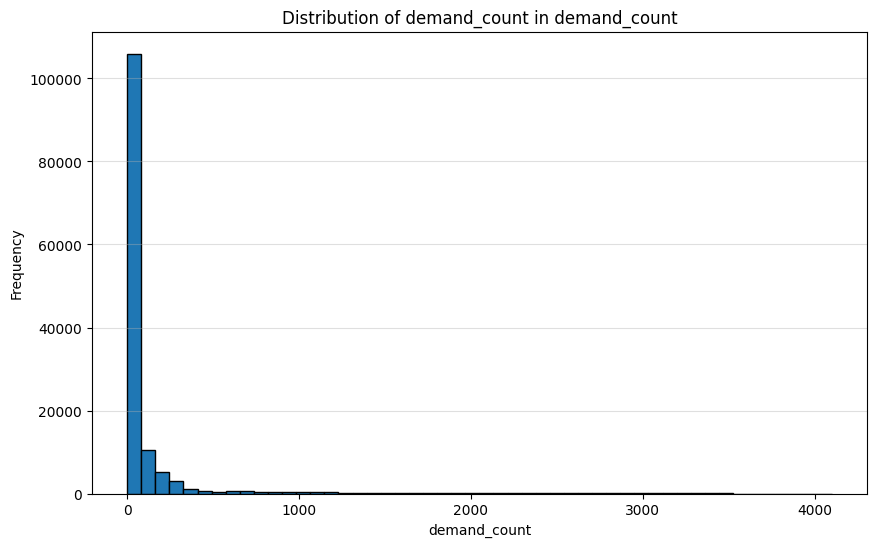

In [22]:
print("H3 r6 × 4h demand distribution:")
print(df_agg_add_weather["demand_count"].describe(percentiles=[.25, .5, .75, .95, .99]))

fig, ax = plot_demand_distribution(df_agg_add_weather["demand_count"])
plt.show()

### Step 6: Calculate idle time
Idle time is the gap between when a taxi ends one trip and when it starts the next trip. It represents the time a driver is available but not carrying a passenger.

In [23]:
# Idle time on a SLIM 3-column frame, not a full copy of df.
# A full df.sort_values() would duplicate the entire ~25-column frame in memory;
# idle only needs taxi_id + the two timestamps.
_idle = df[["taxi_id", "trip_start_timestamp", "trip_end_timestamp"]].sort_values(
    ["taxi_id", "trip_start_timestamp"]
)
_idle["prev_trip_end"] = _idle.groupby("taxi_id", observed=True)["trip_end_timestamp"].shift(1)
_idle["idle_seconds"] = (
    _idle["trip_start_timestamp"] - _idle["prev_trip_end"]
).dt.total_seconds()


Note:
- Very large idle gaps are not real idle time: if a taxi ends a trip on Monday and starts again on Thursday, the gap would include off-shift time, not operational idling. Therefore, to get valid inter-trip gaps, we filter the idle time not longer than 4 hours

In [24]:
# Valid inter-trip gaps only (0 to 4 hours).
valid_idle = _idle[_idle["idle_seconds"].between(0, 4 * 3600)].copy()

# Bring back the columns the Task 2 idle aggregates need. valid_idle is a row-subset
# of df, so the index aligns and this join is exact (no data invented).
valid_idle = valid_idle.join(
    df[["trip_id", "day_of_week", "hour", "h3_r6", "time_1h", "time_4h", "pickup_community_area"]]
)

# Average idle time per taxi
avg_idle_per_taxi = valid_idle.groupby("taxi_id", observed=True)["idle_seconds"].mean()

print(f"valid_idle: {len(valid_idle):,} rows")


valid_idle: 12,053,237 rows


In [25]:
# Calculate average idle time across spatial and temporal units
idle_by_location_time = (
    valid_idle
    .groupby(["h3_r6", "time_4h"])["idle_seconds"]
    .mean()
    .reset_index()
    .rename(columns={"h3_r6": "location_id", "time_4h": "timestamp", "idle_seconds": "avg_idle_seconds"})
)
idle_by_location_time

,location_id,timestamp,avg_idle_seconds
0,862664197ffffff,2024-01-01 08:00:00,1200.0
1,862664197ffffff,2024-01-01 12:00:00,1800.0
2,862664197ffffff,2024-01-01 16:00:00,1200.0
3,862664197ffffff,2024-01-01 20:00:00,3000.0
4,862664197ffffff,2024-01-02 00:00:00,8100.0
...,...,...,...
113683,86275936fffffff,2026-03-31 04:00:00,2700.0
113684,86275936fffffff,2026-03-31 08:00:00,3060.0
113685,86275936fffffff,2026-03-31 12:00:00,2700.0
113686,86275936fffffff,2026-03-31 16:00:00,1620.0


In [26]:
import gc

# Free the slim idle intermediate; valid_idle (the subset we need) is already extracted.
for _name in ["_idle", "df_sorted"]:
    if _name in dir():
        del globals()[_name]
gc.collect()

# df is already memory-lean: H3 columns were built as Categorical (cell with the H3 loop)
# and df_full was downcast before filtering, so df inherited compact dtypes.
# Downcast any remaining wide numeric columns, keeping coordinates at full precision.
_keep_full = {"pickup_centroid_latitude", "pickup_centroid_longitude",
              "dropoff_centroid_latitude", "dropoff_centroid_longitude"}
for c in df.select_dtypes("float").columns:
    if c not in _keep_full:
        df[c] = pd.to_numeric(df[c], downcast="float")
for c in df.select_dtypes("integer").columns:
    df[c] = pd.to_numeric(df[c], downcast="integer")

gc.collect()
print(f"df now: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")


df now: 5.18 GB


In [27]:
# Optional memory diagnostic (safe to skip). Requires psutil.
try:
    import psutil
    mem = psutil.virtual_memory()
    print(f"Total RAM:     {mem.total/1e9:5.1f} GB")
    print(f"Available RAM: {mem.available/1e9:5.1f} GB")
    print(f"df in memory:  {df.memory_usage(deep=True).sum()/1e9:5.1f} GB")
except ModuleNotFoundError:
    print(f"df in memory:  {df.memory_usage(deep=True).sum()/1e9:5.1f} GB  (install psutil for RAM totals)")


Total RAM:       8.3 GB
Available RAM:   1.3 GB
df in memory:    5.2 GB


### Step 7: Save relevant files for following tasks

In [28]:
# Check if there are any days without any demand in df
all_dates = pd.to_datetime(df["date"]).dt.normalize()
full_range = pd.date_range(all_dates.min(), all_dates.max(), freq="D")
present = set(all_dates.unique())
missing = [d for d in full_range if d not in present]
print(f"Date span: {all_dates.min().date()} → {all_dates.max().date()}")
print(f"Calendar days in span: {len(full_range)} | present: {len(present)} | missing: {len(missing)}")
if missing:
    print("Missing dates:", [str(d.date()) for d in missing[:20]])

Date span: 2024-01-01 → 2026-04-01
Calendar days in span: 822 | present: 822 | missing: 0


In [29]:
import pathlib

PROCESSED = pathlib.Path("../processed")
PROCESSED.mkdir(exist_ok=True)

# ── 2.1 — city-level temporal aggregates ────────────────────────────────────
agg_city_dow_hour = (
    df.groupby(["day_of_week", "hour"], observed=True)
      .agg(n_trips         =("trip_id",      "size"),
           mean_trip_miles =("trip_miles",   "mean"),
           mean_trip_secs  =("trip_seconds", "mean"),
           mean_trip_total =("trip_total",   "mean"))
      .reset_index()
)

_ym = df["trip_start_timestamp"].dt.to_period("M").dt.to_timestamp()
agg_city_month = (
    df.assign(month_start=_ym)
      .groupby("month_start", observed=True)
      .agg(n_trips=("trip_id", "size"))
      .reset_index()
)

idle_city_dow_hour = (
    valid_idle.groupby(["day_of_week", "hour"], observed=True)
              .agg(mean_idle_secs=("idle_seconds", "mean"),
                   n             =("idle_seconds", "size"))
              .reset_index()
)

# ── 2.2 — spatial choropleth aggregates (summed over all time) ──────────────
agg_h3r4_total = df.groupby("h3_r4", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r5_total = df.groupby("h3_r5", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r6_total = df.groupby("h3_r6", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r7_total = df.groupby("h3_r7", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r8_total = df.groupby("h3_r8", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_ca_total = (
    df["pickup_community_area"]
      .value_counts(dropna=True)
      .reset_index()
      .rename(columns={"count": "n_trips"})
)

# ── 2.2 — point coordinates for GMM / KDE (+ 2.1 baseline distributions) ────
slim_trips = df[[
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "trip_miles", "trip_seconds", "trip_total",
]].copy()

# ── 2.3 — spatio-temporal aggregate (finest key → collapses both ways) ──────
agg_h3r6_dow_hour = (
    df.groupby(["h3_r6", "day_of_week", "hour"], observed=True)
      .agg(n_trips=("trip_id", "size"))
      .reset_index()
)

# ── 2.4 — Origin-Destination flows at Community Area level ──────────────────
agg_od_ca = (
    df[["pickup_community_area", "dropoff_community_area", "trip_miles", "trip_total"]]
      .dropna(subset=["pickup_community_area", "dropoff_community_area"])
      .groupby(["pickup_community_area", "dropoff_community_area"], observed=True)
      .agg(n_trips         =("trip_miles",  "size"),
           mean_trip_miles =("trip_miles",  "mean"),
           mean_trip_total =("trip_total",  "mean"))
      .reset_index()
)

# ── denominators: distinct dates, for honest "mean demand per day" ──────────
calendar_counts = (
    df.groupby("day_of_week", observed=True)["date"].nunique()
      .reset_index().rename(columns={"date": "n_dates"})
)
# total distinct dates is recoverable in Task 2 as calendar_counts["n_dates"].sum();
# attrs are NOT persisted by parquet, so we do not rely on them.

# ── assemble everything (new aggregates + already-built datasets) ───────────
idle_per_trip = valid_idle[[
    "trip_id", "time_1h", "time_4h", "h3_r6", "pickup_community_area", "idle_seconds",
]].copy()

# Trip-level export for resolution sensitivity in 2.7
df_trips_full = df[[
    "trip_id", "trip_start_timestamp",
    "h3_r4", "h3_r5", "h3_r6", "h3_r7", "h3_r8",
    "pickup_community_area", "pickup_census_tract",
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "trip_miles", "trip_seconds", "trip_total",
    "fare", "tips", "payment_type", "company",
    "avg_speed_mph", "price_per_mile",
]].copy()

datasets = {
    # 2.1
    "agg_city_dow_hour":  agg_city_dow_hour,
    "agg_city_month":     agg_city_month,
    "idle_city_dow_hour": idle_city_dow_hour,
    # 2.2
    "agg_h3r4_total":     agg_h3r4_total,
    "agg_h3r5_total":     agg_h3r5_total,
    "agg_h3r6_total":     agg_h3r6_total,
    "agg_h3r7_total":     agg_h3r7_total,
    "agg_h3r8_total":     agg_h3r8_total,
    "agg_ca_total":       agg_ca_total,
    "slim_trips":         slim_trips,
    # 2.3
    "agg_h3r6_dow_hour":  agg_h3r6_dow_hour,
    "calendar_counts":    calendar_counts,
    # 2.4
    "agg_od_ca":          agg_od_ca, #origin-destination flows at community area level
    # shared / already built
    "idle_per_trip":      idle_per_trip,
    "df_weather_hours":   df_weather_hours,
    "df_weather_4hours":  df_weather_4hours,
    "df_agg_r6_4h":       df_agg_add_weather,
    "df_trips_full":      df_trips_full
}

for name, obj in datasets.items():
    path = PROCESSED / f"{name}.parquet"
    obj.to_parquet(path, index=False)
    size_mb = path.stat().st_size / 1e6
    print(f"{name:<22} {obj.shape[0]:>10,} rows × {obj.shape[1]:>2} cols   {size_mb:>7.1f} MB")

print(f"\ntotal distinct dates: {int(df['date'].nunique()):,}")
print(f"Saved to: {PROCESSED.resolve()}")


agg_city_dow_hour             168 rows ×  6 cols       0.0 MB
agg_city_month                 28 rows ×  2 cols       0.0 MB
idle_city_dow_hour            168 rows ×  4 cols       0.0 MB
agg_h3r4_total                  4 rows ×  2 cols       0.0 MB
agg_h3r5_total                  8 rows ×  2 cols       0.0 MB
agg_h3r6_total                 27 rows ×  2 cols       0.0 MB
agg_h3r7_total                128 rows ×  2 cols       0.0 MB
agg_h3r8_total                475 rows ×  2 cols       0.0 MB
agg_ca_total                   77 rows ×  2 cols       0.0 MB
slim_trips             14,382,862 rows ×  5 cols     103.5 MB
agg_h3r6_dow_hour           4,408 rows ×  4 cols       0.0 MB
calendar_counts                 7 rows ×  2 cols       0.0 MB
agg_od_ca                   5,705 rows ×  5 cols       0.1 MB
idle_per_trip          12,053,237 rows ×  6 cols     548.8 MB
df_weather_hours           19,728 rows ×  7 cols       0.2 MB
df_weather_4hours           4,932 rows ×  7 cols       0.1 MB
df_agg_r

In [30]:
import pyarrow as pa
import pyarrow.parquet as pq
import pathlib, gc

PROCESSED = pathlib.Path("../processed")
PROCESSED.mkdir(exist_ok=True)
path = PROCESSED / "df_trips_full.parquet"

print(f"df memory: {df.memory_usage(deep=True).sum()/1e9:.2f} GB, {len(df):,} rows")

chunk_size = 1_000_000
writer = None
try:
    for start in range(0, len(df), chunk_size):
        chunk = df.iloc[start:start + chunk_size]
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(path, table.schema)
        writer.write_table(table)
        del chunk, table
        gc.collect()
        print(f"  wrote rows {start:,}–{min(start+chunk_size, len(df)):,}")
finally:
    if writer is not None:
        writer.close()

size_gb = path.stat().st_size / 1e9
print(f"\nSaved {path.name}: {size_gb:.2f} GB on disk")

df memory: 5.18 GB, 14,382,862 rows
  wrote rows 0–1,000,000
  wrote rows 1,000,000–2,000,000
  wrote rows 2,000,000–3,000,000
  wrote rows 3,000,000–4,000,000
  wrote rows 4,000,000–5,000,000
  wrote rows 5,000,000–6,000,000
  wrote rows 6,000,000–7,000,000
  wrote rows 7,000,000–8,000,000
  wrote rows 8,000,000–9,000,000
  wrote rows 9,000,000–10,000,000
  wrote rows 10,000,000–11,000,000
  wrote rows 11,000,000–12,000,000
  wrote rows 12,000,000–13,000,000
  wrote rows 13,000,000–14,000,000
  wrote rows 14,000,000–14,382,862

Saved df_trips_full.parquet: 1.12 GB on disk


### Summary of datasets created in 1.6

Section 1.6 transforms the cleaned trip-level data into the demand datasets used in Tasks 2 and 3.
The trip-level frame `df` (hard exclusions applied, pickup coordinates present) is the source for
everything below; all outputs are saved to `../processed/` as parquet.

**Trip-level source**

| Object | Grain | Notes |
|---|---|---|
| `df` | one row per trip | Adds H3 cell IDs (`h3_r4`–`h3_r8`) and time buckets (`time_1h`, `time_4h`, `time_8h`, `time_1d`) to the 1.5 features. Saved as `df_trips_full.parquet`. |

**Canonical modeling dataset**

| Object | Grain | Key columns |
|---|---|---|
| `df_agg_add_weather` | H3 r6 × 4-hour bin | `demand_count` (zero-filled), `avg_trip_miles/seconds/total`, `n_unique_taxis`, merged 4-hour weather. Saved as `df_agg_r6_4h.parquet`. The starting point for Task 3. |

**Descriptive aggregates (for Task 2)**

| Object | Grain | Key columns |
|---|---|---|
| `agg_city_dow_hour` | day-of-week × hour | `n_trips`, `mean_trip_miles/secs/total` |
| `agg_city_month` | calendar month | `n_trips` |
| `idle_city_dow_hour` | day-of-week × hour | `mean_idle_secs`, `n` |
| `agg_h3r4_total` … `agg_h3r8_total` | H3 cell (per resolution) | `n_trips` |
| `agg_ca_total` | community area | `n_trips` |
| `agg_h3r6_dow_hour` | H3 r6 × day-of-week × hour | `n_trips` |
| `slim_trips` | trip | pickup coordinates + `trip_miles/seconds/total` (for GMM/KDE) |
| `calendar_counts` | day-of-week | `n_dates` — denominator for mean-per-day |
| `idle_per_trip` | trip (with valid idle gap) | `idle_seconds` + join keys |

**Key conventions**

- **`demand_count` vs `n_trips`:** `df_agg_add_weather` uses zero-filled `demand_count` (modeling); descriptive aggregates use observed-only `n_trips`.
- **Soft exclusions** apply to characteristic means only (zero-mile dropped from distance, zero-second from duration, `trip_total > 200` from fare) — all such trips still count in `demand_count`/`n_trips`.
- **Mean per day/hour** = summed `n_trips` ÷ relevant date count from `calendar_counts` (counts zero-demand periods correctly).
- **H3 cells are a uniform geometric grid**, not city districts; r6 (~3 km) is canonical. Census tracts excluded (55.65% missing, see 1.3).

### 1.7. Summary

#### 1.1 Dataset Overview

Key findings:
- `pickup_census_tract`: **55.65% missing** - not suitable as the main spatial unit
- `pickup_community_area`: **2.79% missing** - reliable, used as the primary spatial unit
- Pickup coordinates (lat/lon): **2.74% missing** - reliable, used for H3 hexagons
- All other core columns (timestamps, trip miles, trip total) have <1% missing

This part establishes which columns can actually be used for aggregation without losing large portions of data. Census Tracts are immediately flagged as unreliable for absolute demand estimates.



#### 1.2 Syntactical Cleaning

Key findings: No fully duplicated rows or duplicate Trip IDs. A small number of numeric columns gained additional NaNs after type conversion (e.g. `trip_total` +1,783 rows)


#### 1.3 Missing Value Strategy

Key findings: 
- Missing `pickup_community_area` is spread evenly across hours (+/– a few % per hour) and months (2.49%–3.01%) - removing these rows will not distort temporal patterns
- Small taxi companies show higher missing rates but represent a negligible share of total trips
- `pickup_community_area` and pickup coordinates are missing for virtually the same rows (only 7,566 rows differ)


#### 1.4 Semantic Validation & Outlier Handling

Key findings & decisions:

| Flag | Rows affected | Decision |
|---|---|---|
| `end_before_start` (timestamp error) | 98 | Hard exclude |
| `extreme_seconds` (> 3 hours) | ~12,000 (0.08%) | Hard exclude - median duration 9.8h, not real taxi trips |
| `extreme_miles` (> 100 miles) | ~1,200 (0.01%) | Hard exclude - these distances are too long for a taxi trip|
| `invalid_seconds` (= 0 s) | ~202,000 (1.36%) | Soft - still count as pickups, excluded from duration features |
| `zero_miles` (= 0 mi) | ~1.3M (8.75%) | Soft - still count as pickups, excluded from distance features |
| `extreme_total` (> $200) | ~9,500 (0.06%) | Soft - excluded from revenue aggregations only |

Total hard exclusions: ~13,000 rows (0.09%). **99.91% of trips are retained for demand counting.**

Timestamps are rounded to 15-min intervals, causing a structural ~30-min discrepancy with `trip_seconds`. This is expected and not treated as an error. All pickup coordinates fall within Chicago's bounding box.

Demand counts must not drop valid pickup events. Separating hard from soft exclusions ensures that outlier removal only affects the specific features they distort, not the overall trip count.


#### 1.5 Feature Engineering & External Enrichment

**Features created:**

| Group | Columns | Purpose |
|---|---|---|
| Temporal | `hour`, `day_of_week`, `is_weekend`, `month`, `date` | Core demand predictors and time-bucket join keys |
| Spatial | `pickup_h3` (r8) | H3 hexagon IDs at resolution 8 for flexible spatial analysis |
| Operational | `avg_speed_mph` (capped 80 mph, min 60s trips) | Fleet utilisation proxy; ~40% of trips are below 2 mph due to congestion/waiting |
| Monetary | `price_per_mile`, `price_per_minute` | Revenue potential per area; not used as demand predictors |

**Weather data (Open-Meteo, Chicago centroid, 2024–2026):**
- Hourly: temperature, precipitation, rain, snowfall, wind speed, WMO code → joined to 1h and 4h demand tables
- Daily: mean temp, sunshine hours, precipitation sum, max wind → joined to daily aggregations
- One city-centre station used (9km model resolution makes multi-station interpolation unnecessary at 4h granularity)


#### 1.6 Spatial & Temporal Aggregation

**Aggregations produced:** 8 spatial × 4 temporal = 32 combinations (h3 r4–r9, Community Area, Census Tract × 1h, 4h, 8h, 1d).

**Primary dataset chosen: H3 resolution 6 × 4-hour buckets**

**Sparsity findings (zero-demand cells after fill):**

| Resolution | Zero cells | Notes |
|---|---|---|
| H3 r6 × 4h | Very low | **Chosen as primary** |
| Community Area × 4h / 8h / 1d  | Moderate | More zero cells |
| H3 r7/r8/r9 × 1h | High–Very high | Too sparse for reliable modeling |
| Census Tract × any | Extremely high | Sensitivity analysis only |

Excluding the 0–5 AM window (near-zero demand universally) meaningfully reduces sparsity for all 1h datasets and the 0 AM bucket for 4h datasets.

**Demand distribution:** Strongly right-skewed - most (location, time) cells have low or zero demand; a small number of peak cells (high-demand areas, peak hours) have very high counts. The median is far below the mean.

**Idle time:** Calculated as the gap between consecutive trips per taxi, capped at 4 hours to exclude off-shift gaps. Aggregated by H3 r6 and 4h bucket. High idle = local over-supply or weak demand.

This step produces the actual modeling input. The choice of H3 r6 × 4h balances spatial granularity (~10 km² hexagons), temporal resolution, and manageable sparsity. Explicit zero-demand cells are required so that models learn the absence of demand, not just its presence. Idle time feeds into Task 2 as a supply-pressure feature and into Task 3 for repositioning analysis.
